In [2]:
# autoreload modules when code is run. Otherwise, python will not see recent changes. 
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({"axes.grid":True,"grid.color":"black","grid.alpha":"0.25","grid.linestyle":"--"})
plt.rcParams.update({'font.size': 14})

In [5]:
## data from world bank might be nicer to work with than euro stats! 
## contains gdp growth and gdp per capita growth

In [6]:
#filename_world_bank = 'gdp_growth_world_bank.xlsx'
filename_world_bank_update = 'gdp_growth_world_bank_update.xlsx'
gdp_world_bank = pd.read_excel(filename_world_bank_update)
gdp_world_bank.head(5)

,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Austria,AUT,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Belgium,BEL,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Greece,GRC,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Italy,ITA,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,Lithuania,LTU,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175


In [7]:

## TODO REMOVE SERIES CODE AND CHANGE TO LONG FORMAT, PART IN [] SHOULD BE DELETED 
## delete irrelevant columns
del gdp_world_bank["Series Code"]
del gdp_world_bank["Country Code"]
gdp_world_bank.head(5)


# Removing the part in brackets
gdp_world_bank.columns = [name.split(' [')[0] for name in gdp_world_bank.columns]
gdp_world_bank.head(5)

## rename variables 
gdp_world_bank.rename(columns = {'Series Name':'Variable'}, inplace=True)
gdp_world_bank.rename(columns = {'Country Name':'Countries'}, inplace=True)




In [8]:
gdp_world_bank.columns

Index(['Variable', 'Countries', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022'],
      dtype='object')

In [9]:
gdp_world_bank

,Variable,Countries,2000,2001,2002,2003,2004,2005,2006,2007,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,GDP growth (annual %),Austria,3.375722,1.267168,1.651554,0.941471,2.735120,2.244065,3.454042,3.727415,...,0.025505,0.661273,1.014502,1.989437,2.258572,2.425385,1.450529,-6.632991,4.237867,4.806430
1,GDP growth (annual %),Belgium,3.716679,1.099619,1.706885,1.037983,3.571204,2.321737,2.552350,3.676881,...,0.459242,1.578533,2.041459,1.266686,1.619580,1.792945,2.240835,-5.260779,6.850996,3.009903
2,GDP growth (annual %),Greece,3.919771,4.131612,3.922872,5.794532,5.060992,0.599142,5.652434,3.273747,...,-2.515997,0.475696,-0.196088,-0.487173,1.092149,1.668429,1.879490,-9.316436,8.379944,5.557287
3,GDP growth (annual %),Italy,3.786955,1.951372,0.253943,0.138627,1.423594,0.817849,1.790640,1.487073,...,-1.841065,-0.004548,0.778304,1.293463,1.667859,0.925811,0.483198,-8.974192,8.313760,3.724549
4,GDP growth (annual %),Lithuania,3.695525,6.526109,6.751415,10.565957,6.569490,7.732368,7.414121,11.107480,...,3.550073,3.537010,2.024584,2.518828,4.282597,3.993310,4.665678,-0.024612,6.284710,2.440175
5,GDP growth (annual %),Portugal,3.816178,1.943672,0.770924,-0.930521,1.788736,0.781848,1.625034,2.506580,...,-0.922645,0.792190,1.792046,2.019485,3.506345,2.849326,2.682760,-8.300517,5.737437,6.827511
6,GDP growth (annual %),Slovenia,3.672372,3.216560,3.505598,2.960260,4.359193,3.797973,5.746397,6.980161,...,-1.029283,2.768159,2.210082,3.191853,4.815381,4.454366,3.522679,-4.240884,8.228500,2.460783
7,GDP growth (annual %),Spain,5.245944,3.933003,2.730948,2.981936,3.122734,3.652084,4.102686,3.604738,...,-1.403342,1.395775,3.838519,3.037774,2.975761,2.284469,1.983966,-11.167298,6.403174,5.770648
8,GDP growth (annual %),Romania,2.461263,5.218136,5.702992,2.341147,10.428113,4.668148,8.028811,7.233808,...,0.269964,4.120675,3.160504,2.857546,8.196507,6.029019,3.853164,-3.677511,5.708895,4.595361
9,GDP growth (annual %),Luxembourg,6.938130,3.074355,3.225417,2.619379,4.231891,2.482875,6.016715,8.098668,...,3.171790,2.623086,2.269784,4.978190,1.317188,1.219322,2.915848,-0.909830,7.168402,1.380186


In [10]:
gdp_growth_long = pd.melt(gdp_world_bank, id_vars=['Countries'], value_vars = ['2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010',
                                                                                '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020','2021','2022'],
var_name='year', value_name='annual_gdp_growth')
gdp_growth_long.head(800)


,Countries,year,annual_gdp_growth
0,Austria,2000,3.375722
1,Belgium,2000,3.716679
2,Greece,2000,3.919771
3,Italy,2000,3.786955
4,Lithuania,2000,3.695525
...,...,...,...
616,Slovak Republic,2022,1.750448
617,Latvia,2022,3.358474
618,Bulgaria,2022,3.926432
619,Czechia,2022,2.351004


# Descriptive Statistics

In [14]:
## christian's code
# Sorting the countries together
gdp_growth_long_sort = gdp_growth_long.sort_values(['Countries','year'])

# calculating the deviation from mean
# First i calculate mean gdp growth per country over all years
gdp_growth_mean = gdp_growth_long_sort.groupby('Countries')['annual_gdp_growth'].mean().rename('country_mean_gdp_growth')

# Joining the mean gdp growth back to the original dataframe
gdp_growth = gdp_growth_long_sort.join(gdp_growth_mean, on='Countries')

# Calculating the deviation from each country's mean gdp growth
gdp_growth['gdp_mean_dev'] = gdp_growth['annual_gdp_growth'] - gdp_growth['country_mean_gdp_growth']

gdp_growth.head(30)


,Countries,year,annual_gdp_growth,country_mean_gdp_growth,gdp_mean_dev
0,Austria,2000,3.375722,1.511706,1.864016
27,Austria,2001,1.267168,1.511706,-0.244538
54,Austria,2002,1.651554,1.511706,0.139847
81,Austria,2003,0.941471,1.511706,-0.570236
108,Austria,2004,2.735120,1.511706,1.223414
135,Austria,2005,2.244065,1.511706,0.732359
162,Austria,2006,3.454042,1.511706,1.942335
189,Austria,2007,3.727415,1.511706,2.215709
216,Austria,2008,1.460424,1.511706,-0.051283
243,Austria,2009,-3.764578,1.511706,-5.276285


In [15]:
gdp_growth_long.head(50)

,Countries,year,annual_gdp_growth
0,Austria,2000,3.375722
1,Belgium,2000,3.716679
2,Greece,2000,3.919771
3,Italy,2000,3.786955
4,Lithuania,2000,3.695525
5,Portugal,2000,3.816178
6,Slovenia,2000,3.672372
7,Spain,2000,5.245944
8,Romania,2000,2.461263
9,Luxembourg,2000,6.938130


In [16]:
# Annahme: gdp_growth_long ist dein DataFrame im long-Format mit den Spalten 'Countries', 'year' und 'gdp_growth'

# Finde das Land mit dem niedrigsten Wert in der Spalte 'gdp_growth' für jedes Jahr
min_growth_per_year = gdp_growth.groupby('year')['annual_gdp_growth'].idxmin()

# Extrahiere das entsprechende Land für jedes Jahr
countries_with_min_growth_per_year = gdp_growth.loc[min_growth_per_year, ['year', 'Countries', 'annual_gdp_growth']]

print("Countries with the lowest annual gdp growth for each year:")
print(countries_with_min_growth_per_year)



Countries with the lowest annual gdp growth for each year:
     year        Countries  annual_gdp_growth
22   2000  Slovak Republic           1.166527
53   2001            Malta          -1.174697
65   2002          Germany          -0.197974
86   2003         Portugal          -0.930521
134  2004            Malta           0.140269
137  2005           Greece           0.599142
167  2006         Portugal           1.625034
207  2007          Hungary           0.277373
232  2008          Estonia          -5.132001
247  2009        Lithuania         -14.838608
272  2010           Greece          -5.477808
299  2011           Greece         -10.149315
326  2012           Greece          -7.086697
366  2013           Cyprus          -6.553078
393  2014           Cyprus          -1.829309
407  2015           Greece          -0.196088
434  2016           Greece          -0.487173
461  2017           Greece           1.092149
489  2018            Italy           0.925811
516  2019            

In [17]:
## country with the highest gdp growth: 

# Finde das Land mit dem niedrigsten Wert in der Spalte 'gdp_growth' für jedes Jahr
max_growth_per_year = gdp_growth.groupby('year')['annual_gdp_growth'].idxmax()

# Extrahiere das entsprechende Land für jedes Jahr
countries_with_max_growth_per_year = gdp_growth.loc[max_growth_per_year, ['year', 'Countries', 'annual_gdp_growth']]

print("Countries with the highest annual gdp growth for each year:")
print(countries_with_max_growth_per_year)


Countries with the highest annual gdp growth for each year:
     year        Countries  annual_gdp_growth
26   2000            Malta          19.681269
31   2001        Lithuania           6.526109
77   2002           Latvia           7.088129
85   2003        Lithuania          10.565957
116  2004          Romania          10.428113
158  2005           Latvia          10.720366
185  2006           Latvia          11.971836
193  2007        Lithuania          11.107480
224  2008          Romania           9.307467
263  2009           Poland           2.832184
292  2010  Slovak Republic           6.716633
313  2011          Estonia           7.263085
347  2012           Latvia           7.042247
377  2013            Malta           5.473356
388  2014          Ireland           8.828999
415  2015          Ireland          24.475253
447  2016           Cyprus           6.454554
485  2017            Malta          10.869269
496  2018          Ireland           8.470295
539  2019           

# Time Series of some specific countries

In [18]:
from collections import Counter
print("Counting how often a EU-country had the highest gdp growth per year: \n",Counter(countries_with_max_growth_per_year.Countries))
print("Counting how often a EU-country had the lowest gdp growth per year: \n", Counter(countries_with_min_growth_per_year.Countries))

Counting how often a EU-country had the highest gdp growth per year: 
 Counter({'Ireland': 6, 'Malta': 4, 'Latvia': 4, 'Lithuania': 3, 'Romania': 2, 'Poland': 1, 'Slovak Republic': 1, 'Estonia': 1, 'Cyprus': 1})
Counting how often a EU-country had the lowest gdp growth per year: 
 Counter({'Greece': 7, 'Malta': 2, 'Portugal': 2, 'Estonia': 2, 'Cyprus': 2, 'Italy': 2, 'Slovak Republic': 1, 'Germany': 1, 'Hungary': 1, 'Lithuania': 1, 'Spain': 1, 'Finland': 1})


In [20]:
## creating own data sets for Ireland, Greece, Malta, Lithuania,Latvia, Portugal, Italy to later get all in one plot 

#I = (gdp_growth_long.Countries == 'Ireland' or 'Greece' or 'Malta' or 'Lithuania' or 'Latvia' or 'Portugal' or 'Italy')
#gdp_long_subset = gdp_growth_long.loc[I,:]

countries_to_select = ['Ireland', 'Greece', 'Malta', 'Lithuania', 'Latvia']
I = gdp_growth['Countries'].isin(countries_to_select)
gdp_long_subset = gdp_growth.loc[I, :]


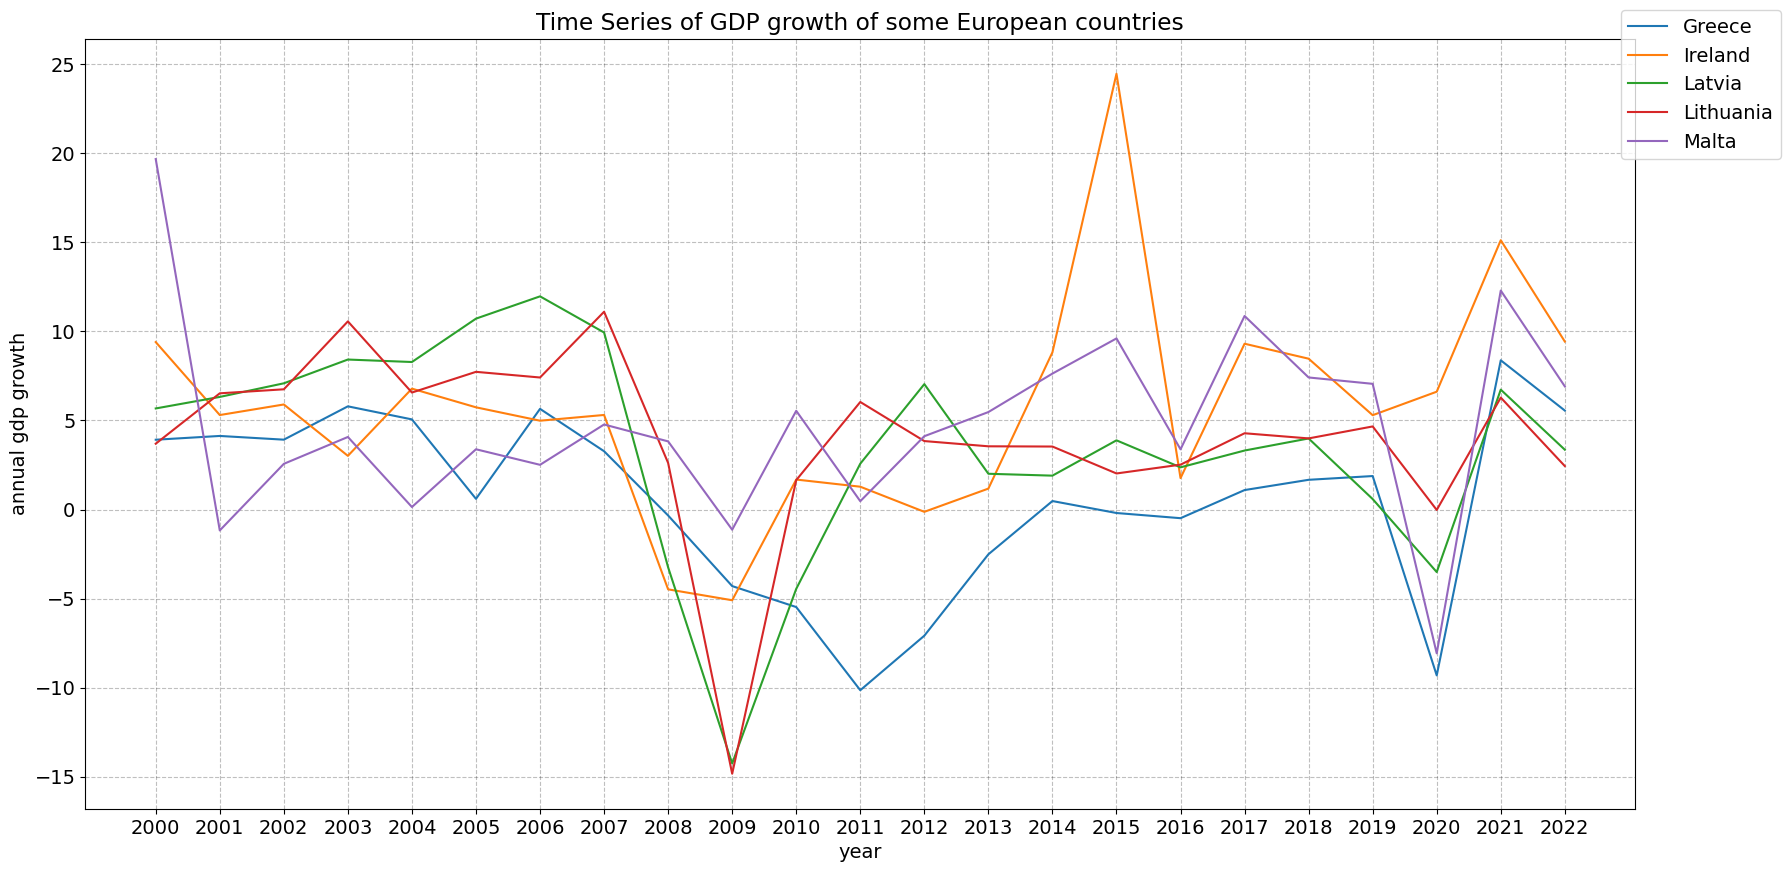

In [27]:
## now we plot some of the outliers (in min and max)


fig = plt.figure(frameon=True,figsize=(20,10), dpi=100)
ax = fig.add_subplot(1,1,1)

# Loop through each country in gdp_long_subset and plot its time series
for country, data in gdp_long_subset.groupby('Countries'):
    ax.plot(data['year'], data['annual_gdp_growth'], label=country)

ax.legend(bbox_to_anchor=(1.1, 1.05))
ax.set_xlabel('year')
ax.set_ylabel('annual gdp growth')
ax.set_title('Time Series of GDP growth of some European countries')


plt.show();



next steps would be to (do interactive plots and) join with the debt data